In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv("../data/indoorAir2.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort by station and time
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()


(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Remove Station id 6
df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()

resample_freq = "1h"

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df["hour"] = feature_df["timestamp"].dt.hour + feature_df["timestamp"].dt.minute / 60
feature_df["dayofweek"] = feature_df["timestamp"].dt.dayofweek

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)

feature_df["dayofweek_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7)
feature_df["dayofweek_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7)

feature_df["is_weekend"] = feature_df["dayofweek"].isin([5, 6]).astype(int)

feature_df = feature_df.drop(columns=["hour", "dayofweek"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()


(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [4]:
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

gap_check = (
    feature_df
    .assign(
        next_timestamp=feature_df.groupby("station_id")["timestamp"].shift(-1)
    )
)

gap_check["next_gap"] = gap_check["next_timestamp"] - gap_check["timestamp"]

print(gap_check["next_gap"].value_counts(dropna=False).head(10))
print(feature_df.shape)

feature_df.head()

next_gap
0 days 01:00:00    46723
NaT                    5
Name: count, dtype: int64
(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [5]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [6]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

outlier_bounds = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).sum(),
        "outlier_percent_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).mean() * 100
    }

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_bounds).T
print(outlier_df)
print(feature_df.shape)
feature_df.head()

                        lower_bound   upper_bound  outlier_count_before  \
ens160_aqi            -5.000000e-01  3.500000e+00                 239.0   
ens160_tvoc           -1.001371e+02  2.916415e+02                4518.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07                   0.0   
bme688_pressure        9.848833e+01  1.018886e+02                1746.0   
scd41_temperature      1.968881e+01  2.915764e+01                 754.0   
scd41_humidity         9.268762e+00  6.307558e+01                  24.0   
scd41_co2              2.498759e+02  7.461140e+02                4962.0   

                       outlier_percent_before  
ens160_aqi                           0.511471  
ens160_tvoc                          9.668721  
bme688_gas_resistance                0.000000  
bme688_pressure                      3.736518  
scd41_temperature                    1.613594  
scd41_humidity                       0.051361  
scd41_co2                           10.618901  
(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [7]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -1.001371e+02  2.916415e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.848833e+01  1.018886e+02            0.0   
scd41_temperature      1.968881e+01  2.915764e+01            0.0   
scd41_humidity         9.268762e+00  6.307558e+01            0.0   
scd41_co2              2.498759e+02  7.461140e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  


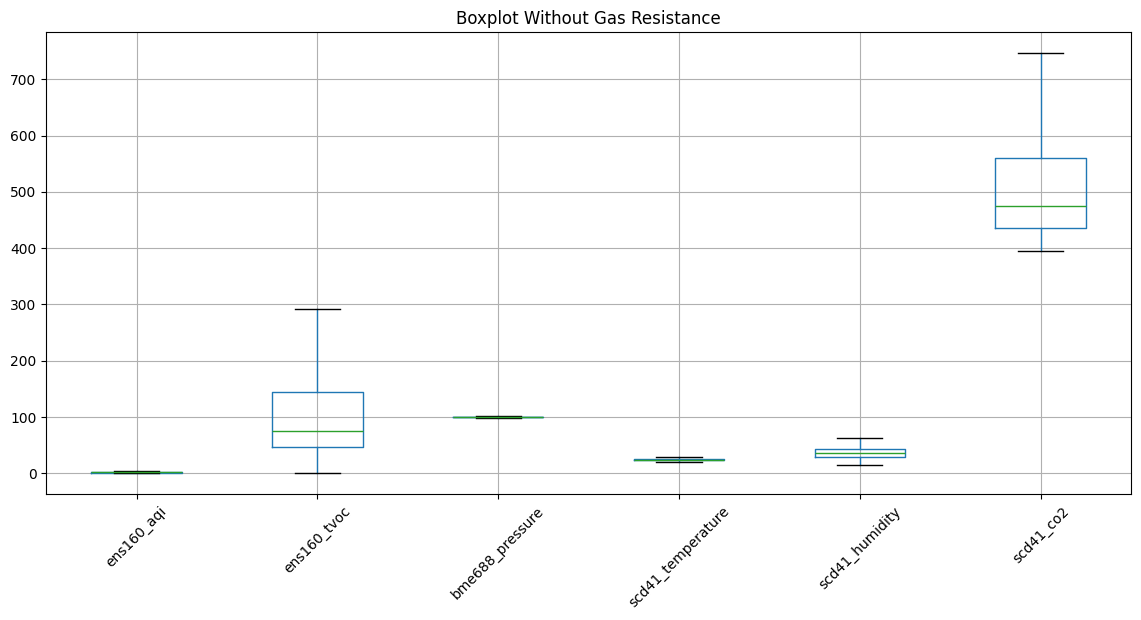

In [8]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [9]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (32707, 14)
Val shape: (7007, 14)
Test shape: (7014, 14)
Train percentage: 69.9944358842664
Val percentage: 14.995291902071564
Test percentage: 15.010272213662043

Rows per station:
            train   val  test
station_id                   
1            8818  1889  1891
2            3392   726   728
3            7729  1656  1657
4            7657  1641  1642
5            5111  1095  1096


In [10]:
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col not in ["timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Input features:", feature_cols)
print("Past CO2 included:", target_col in feature_cols)
print("Scaled X train min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y train min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Past CO2 included: True
Scaled X train min/max: 0.0 1.0
Scaled y train min/max: 0.0 1.0


In [11]:
history_days = 7
forecast_hours = 6
samples_per_hour = int(pd.Timedelta(hours=1) / pd.Timedelta(resample_freq))

input_size = history_days * 24 * samples_per_hour          # 7 days = 168 rows at 1 hour
forecast_horizon_steps = forecast_hours * samples_per_hour # 6 hours = 6 rows at 1 hour

target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col != "timestamp"
]

print(f"History window: {input_size} rows = {history_days} days")
print(f"Forecast horizon: {forecast_horizon_steps} rows = {forecast_hours} hours ahead")
print("Input features:", feature_cols)

def create_windows(data, feature_cols, target_col):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        # Input: previous 7 days at 1-hour resolution
        # Target: CO2 exactly 6 hours after the last input timestamp
        max_start = len(station_data) - forecast_horizon_steps + 1

        for i in range(input_size, max_start):
            target_idx = i + forecast_horizon_steps - 1

            X_windows.append(X[i - input_size:i])
            y_windows.append(y[target_idx])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


History window: 168 rows = 7 days
Forecast horizon: 6 rows = 6 hours ahead
Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
X_train: (31842, 168, 13) y_train: (31842,)
X_val: (6142, 168, 13) y_val: (6142,)
X_test: (6149, 168, 13) y_test: (6149,)


In [12]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 498
Val batches: 96
Test batches: 97


In [13]:
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.25,
        max_len=input_size
    ):
        super().__init__()

        self.input_projection = nn.Linear(num_features, d_model)

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_len, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        seq_len = x.size(1)

        x = self.input_projection(x)
        x = x + self.positional_embedding[:, :seq_len, :]

        x = self.transformer_encoder(x)
        x = x[:, -1, :]

        return self.regressor(x)

In [14]:
num_features = X_train.shape[2]

model = TransformerRegressor(
    num_features=num_features,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.25,
    max_len=input_size
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [15]:
num_epochs = 15
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_transformer_model_1h.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break



Epoch [1/15] Train Loss: 0.047673 Val Loss: 0.038254
Epoch [2/15] Train Loss: 0.030403 Val Loss: 0.035043
Epoch [3/15] Train Loss: 0.026995 Val Loss: 0.035054
Epoch [4/15] Train Loss: 0.024964 Val Loss: 0.033343
Epoch [5/15] Train Loss: 0.023589 Val Loss: 0.032833
Epoch [6/15] Train Loss: 0.022883 Val Loss: 0.034200
Epoch [7/15] Train Loss: 0.022507 Val Loss: 0.033206
Epoch [8/15] Train Loss: 0.022180 Val Loss: 0.034634
Epoch [9/15] Train Loss: 0.021657 Val Loss: 0.034321
Epoch [10/15] Train Loss: 0.020966 Val Loss: 0.030981
Epoch [11/15] Train Loss: 0.020936 Val Loss: 0.032247
Epoch [12/15] Train Loss: 0.020452 Val Loss: 0.032868
Epoch [13/15] Train Loss: 0.020524 Val Loss: 0.033273
Epoch [14/15] Train Loss: 0.020105 Val Loss: 0.032079
Epoch [15/15] Train Loss: 0.019624 Val Loss: 0.033704
Early stopping triggered


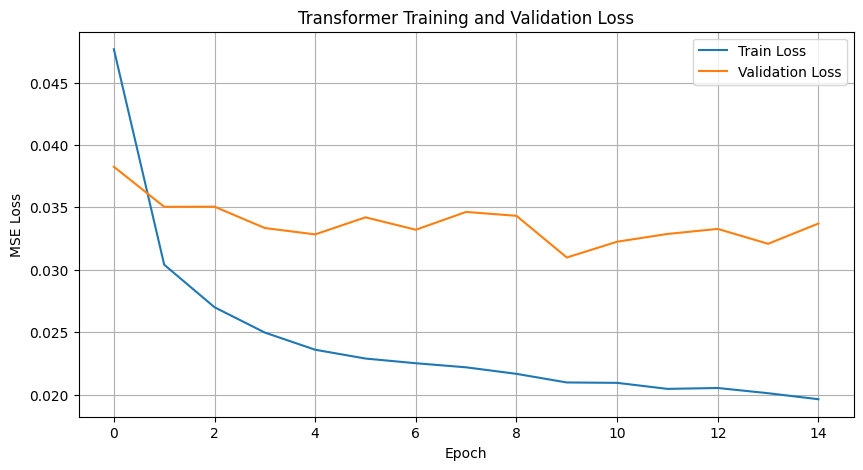

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =====================
# Normalized Metrics
# =====================

mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print("=== Normalized Scale ===")
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("MAE :", mae_scaled)
print("R²  :", r2_scaled)

# =====================
# Original Scale
# =====================

y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n=== Original Scale ===")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

=== Normalized Scale ===
MSE : 0.0023878479842096567
RMSE: 0.04886561146869705
MAE : 0.021358143538236618
R²  : 0.9771915078163147

=== Original Scale ===
MSE : 293.40643310546875
RMSE: 17.129110692194992
MAE : 7.4867777824401855
R²  : 0.9771915078163147


In [17]:
model.load_state_dict(torch.load("best_transformer_model_1h.pth"))
model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch).numpy()

        y_pred_scaled.extend(preds)
        y_true_scaled.extend(y_batch.numpy())

y_true_scaled = np.array(y_true_scaled)
y_pred_scaled = np.array(y_pred_scaled)

# Metrics with MinMax-scaled values
mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print("Metrics WITH MinMax Scaling")
print("Scaled Test MSE:", mse_scaled)
print("Scaled Test RMSE:", rmse_scaled)
print("Scaled Test MAE:", mae_scaled)
print("Scaled Test R2:", r2_scaled)

# Metrics after inverse scaling
y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print()
print("Metrics AFTER Inverse Scaling")
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)



Metrics WITH MinMax Scaling
Scaled Test MSE: 0.016442185267806053
Scaled Test RMSE: 0.12822708476685435
Scaled Test MAE: 0.07898464053869247
Scaled Test R2: 0.8433475494384766

Metrics AFTER Inverse Scaling
Test MSE: 2020.33056640625
Test RMSE: 44.948087461050555
Test MAE: 27.68688201904297
Test R2: 0.8433474898338318


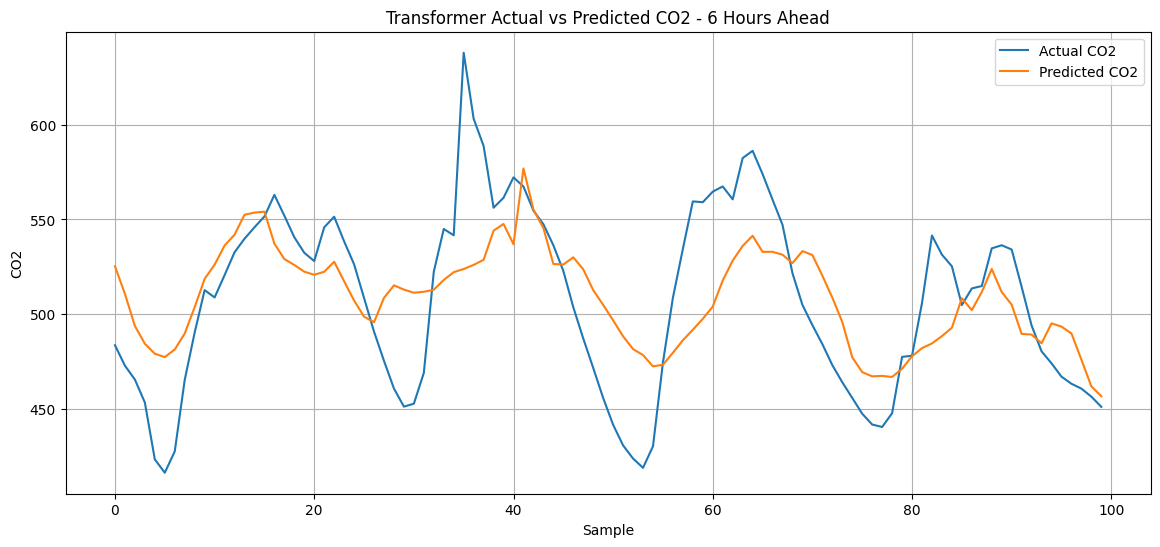

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual CO2")
plt.plot(y_pred[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Transformer Actual vs Predicted CO2 - 6 Hours Ahead")
plt.legend()
plt.grid(True)
plt.show()